# UFO DW — Verificação Geral dos Dados

Notebook de checagem do Data Warehouse após carga. Objetivo: confirmar integridade, qualidade e distribuições básicas antes de prosseguir para análises.

**Aluno:** Erick Bonruque · RA 2587246  
**Disciplina:** CC6IBDDA — Introdução a Big Data e Data Analytics

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from dotenv import load_dotenv

load_dotenv('../.env')
warnings.filterwarnings('ignore')

DW_PATH = os.getenv('DW_PATH', '../data/warehouse/ufo_dw.duckdb')
# ajusta caminho relativo ao notebook
if not os.path.isabs(DW_PATH):
    DW_PATH = os.path.join('..', DW_PATH)

con = duckdb.connect(DW_PATH, read_only=True)
print(f'Conectado: {DW_PATH}')

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

Conectado: ..\data/warehouse/ufo_dw.duckdb


---
## 1. Contagem de linhas por tabela

In [2]:
tabelas = [
    'dim_tempo', 'dim_local', 'dim_formato', 'dim_fonte',
    'dim_clima', 'dim_aeroporto', 'dim_evento_espacial',
    'dim_interesse_cultural', 'fato_avistamento'
]

rows = []
for t in tabelas:
    q = con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    rows.append({'Tabela': t, 'Linhas': q, 'Status': '✅ OK' if q > 0 else '⚠️  Vazia'})

df_counts = pd.DataFrame(rows)
df_counts['Linhas'] = df_counts['Linhas'].map('{:,}'.format)
display(df_counts.style.hide(axis='index'))

Tabela,Linhas,Status
dim_tempo,"1,113,241",✅ OK
dim_local,"24,033",✅ OK
dim_formato,29,✅ OK
dim_fonte,3,✅ OK
dim_clima,"2,400",✅ OK
dim_aeroporto,"24,032",✅ OK
dim_evento_espacial,"4,320",✅ OK
dim_interesse_cultural,570,✅ OK
fato_avistamento,"74,535",✅ OK


---
## 2. Integridade referencial (órfãos)

In [3]:
checks = [
    ('dim_tempo',    'sk_tempo'),
    ('dim_local',    'sk_local'),
    ('dim_formato',  'sk_formato'),
    ('dim_fonte',    'sk_fonte'),
    ('dim_aeroporto','sk_aeroporto'),
]

orfaos = []
for dim, sk in checks:
    q = con.execute(f'''
        SELECT COUNT(*) FROM fato_avistamento fa
        LEFT JOIN {dim} d ON d.{sk} = fa.{sk}
        WHERE d.{sk} IS NULL AND fa.{sk} IS NOT NULL
    ''').fetchone()[0]
    orfaos.append({'Dimensão': dim, 'Chave': sk, 'Órfãos': q,
                   'Status': '✅' if q == 0 else f'❌ {q}'})

display(pd.DataFrame(orfaos).style.hide(axis='index'))

Dimensão,Chave,Órfãos,Status
dim_tempo,sk_tempo,0,✅
dim_local,sk_local,0,✅
dim_formato,sk_formato,0,✅
dim_fonte,sk_fonte,0,✅
dim_aeroporto,sk_aeroporto,0,✅


---
## 3. Qualidade da tabela fato

In [4]:
q = con.execute('''
    SELECT
        COUNT(*)                                              AS total_registros,
        ROUND(100.0 * COUNT(sk_aeroporto)      / COUNT(*), 1) AS pct_com_aeroporto,
        ROUND(100.0 * COUNT(sk_interesse_cultural) / COUNT(*), 1) AS pct_com_interesse,
        ROUND(100.0 * COUNT(duracao_segundos)  / COUNT(*), 1) AS pct_com_duracao,
        ROUND(100.0 * COUNT(lag_reporte_dias)  / COUNT(*), 1) AS pct_com_lag,
        ROUND(AVG(duracao_segundos), 0)                       AS media_duracao_s,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP
              (ORDER BY duracao_segundos), 0)                 AS mediana_duracao_s,
        COUNT(CASE WHEN lag_reporte_dias < 0 THEN 1 END)      AS lag_negativo,
        COUNT(CASE WHEN duracao_segundos > 86400 THEN 1 END)  AS duracao_acima_1dia
    FROM fato_avistamento
''').fetchdf().T

q.columns = ['Valor']
q.index.name = 'Métrica'
display(q)

,Valor
Métrica,
total_registros,74535.0
pct_com_aeroporto,100.0
pct_com_interesse,0.0
pct_com_duracao,100.0
pct_com_lag,100.0
media_duracao_s,6618.0
mediana_duracao_s,180.0
lag_negativo,305.0
duracao_acima_1dia,151.0


---
## 4. Distribuição temporal — avistamentos por ano

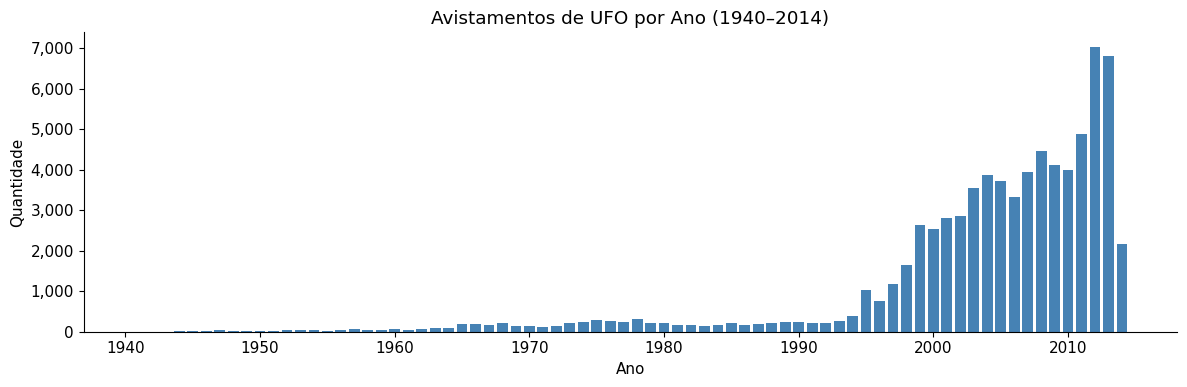

In [5]:
df_ano = con.execute('''
    SELECT t.ano, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_tempo t ON t.sk_tempo = fa.sk_tempo
    WHERE t.ano BETWEEN 1940 AND 2014
    GROUP BY 1 ORDER BY 1
''').fetchdf()

fig, ax = plt.subplots()
ax.bar(df_ano['ano'], df_ano['qtd'], color='steelblue', width=0.8)
ax.set_title('Avistamentos de UFO por Ano (1940–2014)')
ax.set_xlabel('Ano')
ax.set_ylabel('Quantidade')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 5. Distribuição por mês e hora do dia

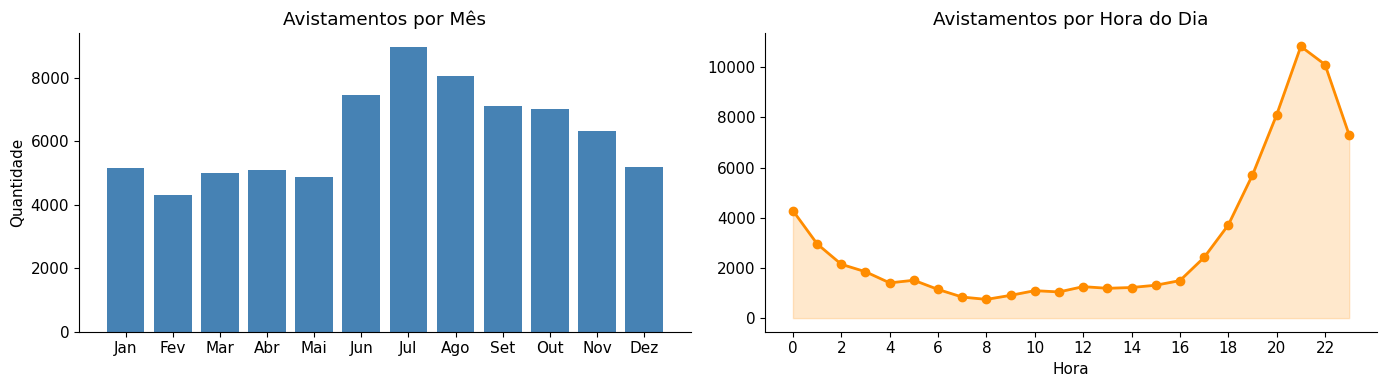

In [6]:
df_mes = con.execute('''
    SELECT t.mes, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_tempo t ON t.sk_tempo = fa.sk_tempo
    GROUP BY 1 ORDER BY 1
''').fetchdf()

df_hora = con.execute('''
    SELECT t.hora, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_tempo t ON t.sk_tempo = fa.sk_tempo
    WHERE t.hora IS NOT NULL
    GROUP BY 1 ORDER BY 1
''').fetchdf()

meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(df_mes['mes'], df_mes['qtd'], color='steelblue')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(meses)
ax1.set_title('Avistamentos por Mês')
ax1.set_ylabel('Quantidade')

ax2.plot(df_hora['hora'], df_hora['qtd'], marker='o', color='darkorange', linewidth=2)
ax2.fill_between(df_hora['hora'], df_hora['qtd'], alpha=0.2, color='darkorange')
ax2.set_title('Avistamentos por Hora do Dia')
ax2.set_xlabel('Hora')
ax2.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

---
## 6. Distribuição geográfica — Top países e estados (EUA)

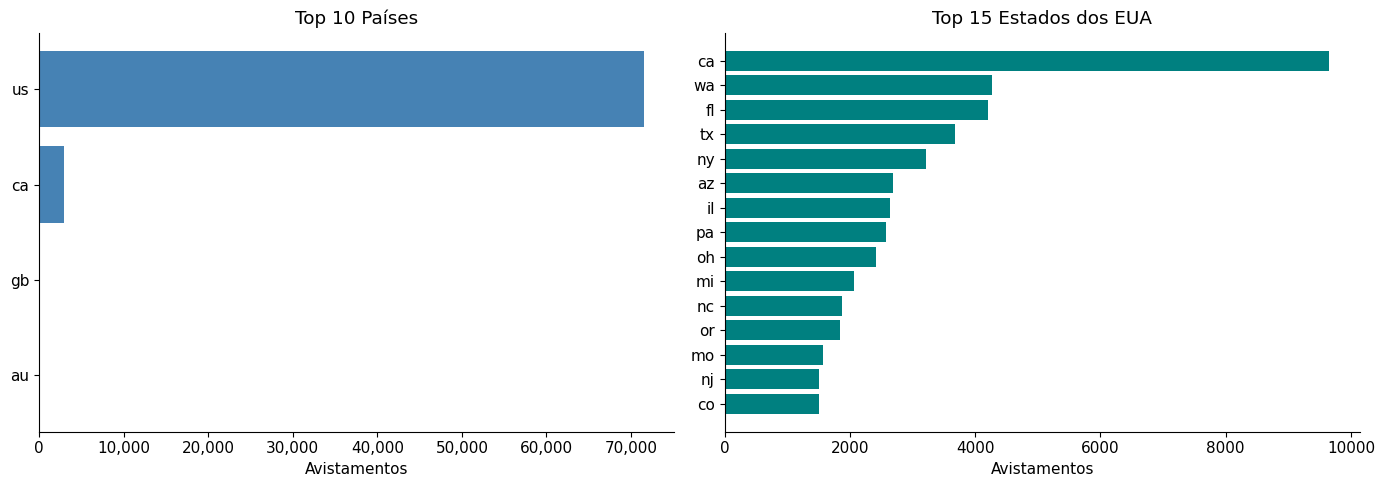

In [7]:
df_pais = con.execute('''
    SELECT l.pais, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_local l ON l.sk_local = fa.sk_local
    GROUP BY 1 ORDER BY 2 DESC LIMIT 10
''').fetchdf()

df_estado = con.execute('''
    SELECT l.estado, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_local l ON l.sk_local = fa.sk_local
    WHERE l.pais = 'us' AND l.estado IS NOT NULL
    GROUP BY 1 ORDER BY 2 DESC LIMIT 15
''').fetchdf()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(df_pais['pais'][::-1], df_pais['qtd'][::-1], color='steelblue')
ax1.set_title('Top 10 Países')
ax1.set_xlabel('Avistamentos')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2.barh(df_estado['estado'][::-1], df_estado['qtd'][::-1], color='teal')
ax2.set_title('Top 15 Estados dos EUA')
ax2.set_xlabel('Avistamentos')

plt.tight_layout()
plt.show()

---
## 7. Formatos (shapes) dos avistamentos

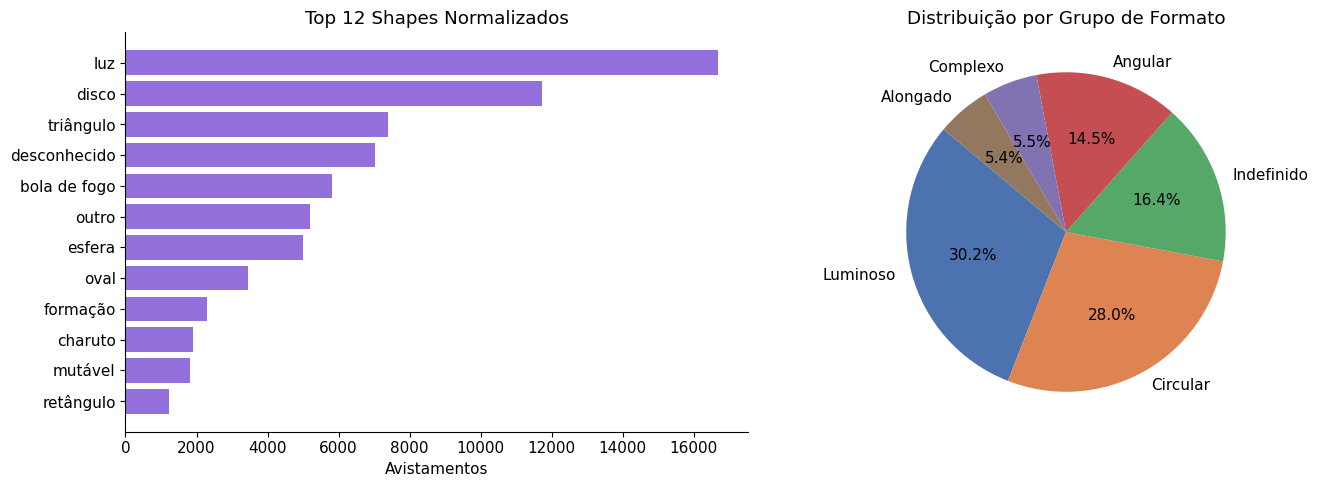

In [8]:
df_shape = con.execute('''
    SELECT f.shape_normalizado, f.grupo_formato, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_formato f ON f.sk_formato = fa.sk_formato
    GROUP BY 1, 2 ORDER BY 3 DESC
''').fetchdf()

df_grupo = con.execute('''
    SELECT f.grupo_formato, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_formato f ON f.sk_formato = fa.sk_formato
    GROUP BY 1 ORDER BY 2 DESC
''').fetchdf()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

top = df_shape.head(12)
ax1.barh(top['shape_normalizado'][::-1], top['qtd'][::-1], color='mediumpurple')
ax1.set_title('Top 12 Shapes Normalizados')
ax1.set_xlabel('Avistamentos')

cores = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
ax2.pie(df_grupo['qtd'], labels=df_grupo['grupo_formato'],
        colors=cores[:len(df_grupo)], autopct='%1.1f%%', startangle=140)
ax2.set_title('Distribuição por Grupo de Formato')

plt.tight_layout()
plt.show()

---
## 8. Duração dos avistamentos

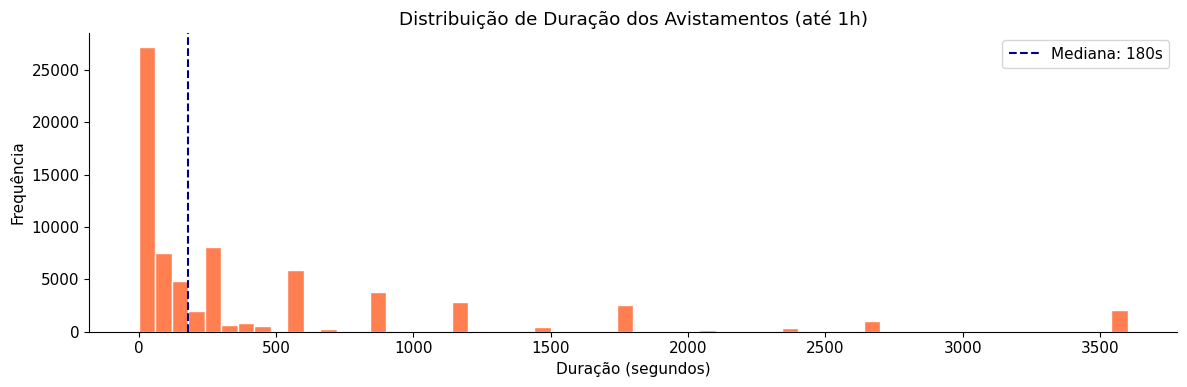

count    71566.0
mean       479.9
std        772.3
min          0.0
25%         30.0
50%        180.0
75%        600.0
max       3600.0
Name: duracao_segundos, dtype: float64


In [9]:
df_dur = con.execute('''
    SELECT duracao_segundos
    FROM fato_avistamento
    WHERE duracao_segundos IS NOT NULL
      AND duracao_segundos > 0
      AND duracao_segundos <= 3600
''').fetchdf()

fig, ax = plt.subplots()
ax.hist(df_dur['duracao_segundos'], bins=60, color='coral', edgecolor='white')
ax.set_title('Distribuição de Duração dos Avistamentos (até 1h)')
ax.set_xlabel('Duração (segundos)')
ax.set_ylabel('Frequência')

p50 = df_dur['duracao_segundos'].median()
ax.axvline(p50, color='navy', linestyle='--', linewidth=1.5, label=f'Mediana: {p50:.0f}s')
ax.legend()
plt.tight_layout()
plt.show()

print(df_dur['duracao_segundos'].describe().round(1))

---
## 9. Interesse cultural (Wikipedia pageviews)

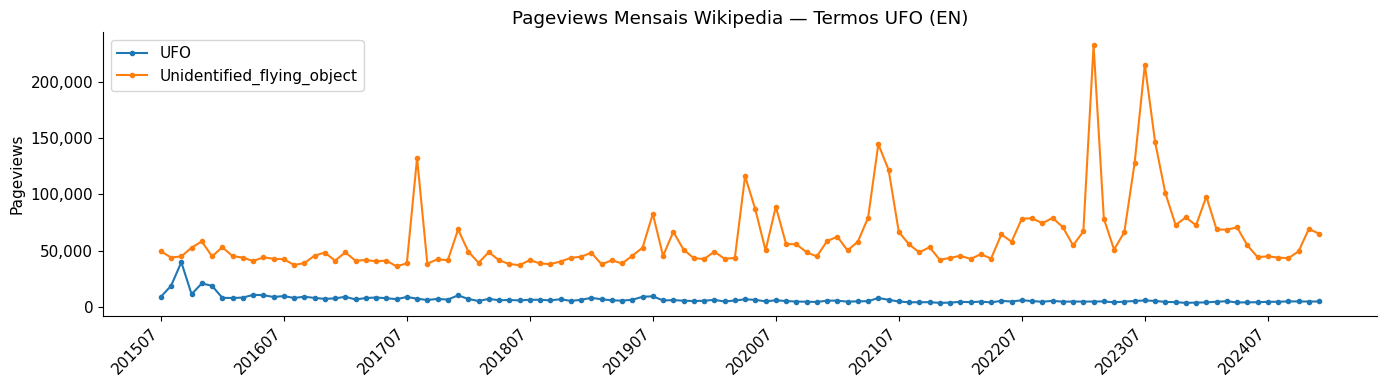

In [10]:
df_wiki = con.execute('''
    SELECT ano_mes, termo, idioma, pageviews_mensais
    FROM dim_interesse_cultural
    WHERE idioma = 'en' AND termo IN (''UFO'', ''Unidentified_flying_object'')
    ORDER BY ano_mes
'''.replace("''", "'")).fetchdf()

fig, ax = plt.subplots(figsize=(14, 4))
for termo, grp in df_wiki.groupby('termo'):
    ax.plot(range(len(grp)), grp['pageviews_mensais'], marker='.', label=termo)

ticks = list(range(0, len(df_wiki['ano_mes'].unique()), 12))
ax.set_xticks(ticks)
ax.set_xticklabels(df_wiki['ano_mes'].unique()[ticks], rotation=45, ha='right')
ax.set_title('Pageviews Mensais Wikipedia — Termos UFO (EN)')
ax.set_ylabel('Pageviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Aeroporto mais próximo — distribuição de distâncias

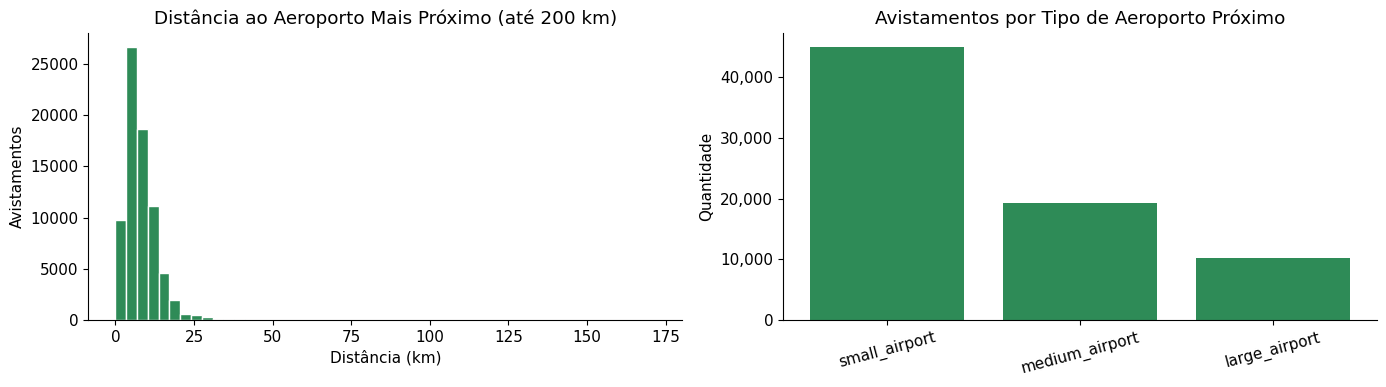

Estatísticas de distância (km):
count    74527.0
mean         8.2
std          5.5
min          0.0
25%          4.6
50%          7.0
75%         10.6
max        171.7
Name: distancia_km, dtype: float64


In [11]:
df_aero = con.execute('''
    SELECT a.distancia_km, a.tipo_aeroporto
    FROM fato_avistamento fa
    JOIN dim_aeroporto a ON a.sk_aeroporto = fa.sk_aeroporto
    WHERE a.distancia_km <= 200
''').fetchdf()

df_tipo = con.execute('''
    SELECT a.tipo_aeroporto, COUNT(*) AS qtd
    FROM fato_avistamento fa
    JOIN dim_aeroporto a ON a.sk_aeroporto = fa.sk_aeroporto
    GROUP BY 1 ORDER BY 2 DESC
''').fetchdf()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(df_aero['distancia_km'], bins=50, color='seagreen', edgecolor='white')
ax1.set_title('Distância ao Aeroporto Mais Próximo (até 200 km)')
ax1.set_xlabel('Distância (km)')
ax1.set_ylabel('Avistamentos')

ax2.bar(df_tipo['tipo_aeroporto'], df_tipo['qtd'], color='seagreen')
ax2.set_title('Avistamentos por Tipo de Aeroporto Próximo')
ax2.set_ylabel('Quantidade')
ax2.tick_params(axis='x', rotation=15)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print('Estatísticas de distância (km):')
print(df_aero['distancia_km'].describe().round(1))

---
## 11. Amostra das tabelas principais

In [12]:
print('=== fato_avistamento (5 linhas) ===')
display(con.execute('SELECT * FROM fato_avistamento LIMIT 5').fetchdf())

print('\n=== dim_local (5 linhas) ===')
display(con.execute('SELECT * FROM dim_local LIMIT 5').fetchdf())

print('\n=== dim_formato (todas) ===')
display(con.execute('SELECT * FROM dim_formato ORDER BY grupo_formato, shape_normalizado').fetchdf())

=== fato_avistamento (5 linhas) ===


,sk_avistamento,sk_tempo,sk_local,sk_formato,sk_fonte,sk_clima,sk_aeroporto,sk_evento_espacial,sk_interesse_cultural,duracao_segundos,lag_reporte_dias,latitude,longitude,quantidade_relato
0,1,573546,4450,3,1,330,18314,<NA>,<NA>,240.0,13519,33.653333,-84.449444,1
1,2,573748,23719,3,1,318,5651,<NA>,<NA>,120.0,13481,34.168333,-118.605000,1
2,3,573764,22035,5,1,594,17076,<NA>,<NA>,10.0,15290,42.626111,-83.033611,1
3,4,573769,23314,9,1,6,295,<NA>,<NA>,5.0,13575,33.979167,-118.031944,1
4,5,573867,259,5,1,786,118,<NA>,<NA>,300.0,12390,35.084444,-106.650556,1



=== dim_local (5 linhas) ===


,sk_local,cidade,estado,pais,latitude,longitude,regiao
0,1,&ccedil;anakkale (turkey),None,us,40.155312,26.414160,América do Norte
1,2,&iacute;safj&ouml;r&eth;ur (iceland),None,us,66.075833,-23.126667,América do Norte
2,3,&ouml;lmstad (sweden),None,us,57.933333,14.366667,América do Norte
3,4,1-25 corridor (southbound&#44 65 miles north n...,co,us,39.792716,-105.083267,América do Norte
4,5,100 mile (canada),bc,us,51.643970,-121.295010,América do Norte



=== dim_formato (todas) ===


,sk_formato,shape_original,shape_normalizado,grupo_formato
0,10,cigar,charuto,Alongado
1,1,cylinder,cilindro,Alongado
2,21,cone,cone,Alongado
3,20,teardrop,lágrima,Alongado
4,12,chevron,chevron,Angular
5,25,crescent,crescente,Angular
6,22,cross,cruz,Angular
7,15,delta,delta,Angular
8,18,diamond,diamante,Angular
9,27,hexagon,hexágono,Angular


---
## 12. Checklist final

In [13]:
checks = {}

# 8 dimensões no schema
dims = con.execute("SELECT COUNT(*) FROM (SHOW TABLES) WHERE name LIKE 'dim_%'").fetchone()[0]
checks['8 dimensões criadas'] = dims == 8

# Fato tem registros
fato_qtd = con.execute('SELECT COUNT(*) FROM fato_avistamento').fetchone()[0]
checks[f'fato_avistamento populada ({fato_qtd:,} linhas)'] = fato_qtd > 0

# Zero órfãos
for dim, sk in [('dim_tempo','sk_tempo'),('dim_local','sk_local'),('dim_formato','sk_formato'),('dim_fonte','sk_fonte')]:
    q = con.execute(f'''
        SELECT COUNT(*) FROM fato_avistamento fa
        LEFT JOIN {dim} d ON d.{sk} = fa.{sk}
        WHERE d.{sk} IS NULL AND fa.{sk} IS NOT NULL
    ''').fetchone()[0]
    checks[f'Zero órfãos em {dim}'] = q == 0

# Tipos de dados
tipos = con.execute("SELECT column_name, data_type FROM information_schema.columns WHERE table_name='fato_avistamento'").fetchdf()
checks['sk_avistamento é BIGINT'] = 'BIGINT' in tipos[tipos['column_name']=='sk_avistamento']['data_type'].values

print('\n📋 Checklist do Modelo Físico:\n')
for item, ok in checks.items():
    icone = '✅' if ok else '❌'
    print(f'  {icone}  {item}')

con.close()
print('\nConexão encerrada.')


📋 Checklist do Modelo Físico:

  ✅  8 dimensões criadas
  ✅  fato_avistamento populada (74,535 linhas)
  ✅  Zero órfãos em dim_tempo
  ✅  Zero órfãos em dim_local
  ✅  Zero órfãos em dim_formato
  ✅  Zero órfãos em dim_fonte
  ✅  sk_avistamento é BIGINT

Conexão encerrada.
